# BOT API Query — Testing the standalone `bot_api` client

This notebook exercises `src/bot_api`, a standalone client for BOT's newer Open Data
gateway (`gateway.api.bot.or.th`), kept separate from the `macro_data` package (which
talks to the older `apigw1.bot.or.th` gateway through the catalog/schema/store
pipeline — see `macro_data/sources/bot.py`). Nothing queried here is written to the
CSV store; this is ad-hoc exploration, same spirit as `fx_ohlcv_query.ipynb`.

Sections:
- Setup — load `BOT_CLIENT_ID` from `.env`, construct a `BOTClient`
- 1. Daily exchange rates (`bot.exchange.daily`)
- 2. Monthly / quarterly / annual exchange rates — note the different `start_period`/`end_period` formats each expects
- 3. Interest (loan) rates (`bot.interest.*`) — requires a separate API-product subscription
- 4. Bond auctions (`bot.bond_auction.auction`) — requires a separate API-product subscription
- 5. Weighted-average interbank reference rate (`bot.reference_rate.*`) — THB/USD only, no subscription gap

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from bot_api import BOTClient

load_dotenv(Path("..") / ".env")
pd.set_option("display.max_columns", 10)
%matplotlib inline

bot = BOTClient()  # reads BOT_CLIENT_ID / BOT_CLIENT_ID_INTEREST / BOT_CLIENT_ID_BOND_AUCTION from the environment
print(f"BOTClient ready, base_url={bot.base_url}")

BOTClient ready, base_url=https://gateway.api.bot.or.th/


## 1. Daily exchange rates

`bot.exchange.daily(start_period, end_period, currency=...)` — `start_period`/`end_period` as `YYYY-MM-DD`.

In [2]:
daily_usd = bot.exchange.daily("2024-01-01", "2024-01-31", currency="USD")
daily_usd.tail()

,period,currency_id,currency_name_th,currency_name_eng,buying_sight,buying_transfer,selling,mid_rate
17,2024-01-08,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),34.5683000,34.6636000,34.9801000,34.8219000
18,2024-01-05,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),34.3376000,34.4168000,34.7289000,34.5729000
19,2024-01-04,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),34.2532000,34.3489000,34.6718000,34.5104000
20,2024-01-03,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),34.0178000,34.1071000,34.4324000,34.2698000
21,2024-01-02,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),33.9954000,34.0938000,34.4143000,34.2541000


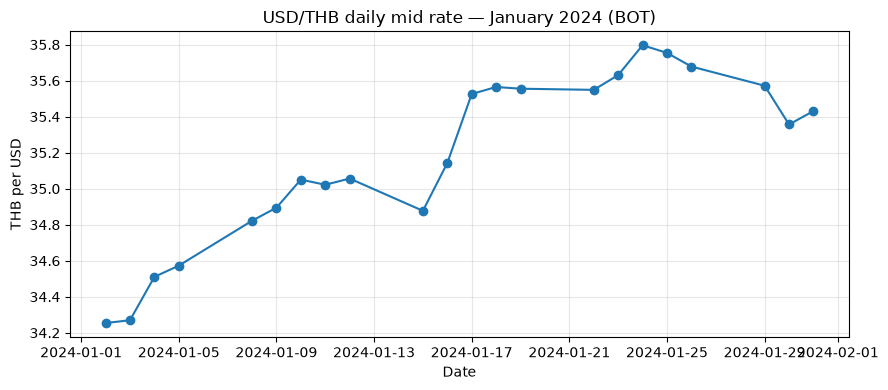

In [3]:
plt.figure(figsize=(9, 4))
plt.plot(daily_usd["period"], daily_usd["mid_rate"].astype(float), marker="o")
plt.title("USD/THB daily mid rate — January 2024 (BOT)")
plt.xlabel("Date")
plt.ylabel("THB per USD")
plt.grid(alpha=0.3)
plt.tight_layout()

## 2. Monthly / quarterly / annual exchange rates

Each frequency expects a different `start_period`/`end_period` format — confirmed against the live gateway (a mismatched format returns `400 Bad Request`):

| Method | Format | Example |
|---|---|---|
| `daily` | `YYYY-MM-DD` | `2024-01-31` |
| `monthly` | `YYYY-MM` | `2024-06` |
| `quarterly` | `YYYY-Q#` | `2024-Q1` |
| `annual` | `YYYY` | `2024` |

In [4]:
monthly_usd = bot.exchange.monthly("2024-01", "2024-06", currency="USD")
quarterly_usd = bot.exchange.quarterly("2024-Q1", "2024-Q2", currency="USD")
annual_usd = bot.exchange.annual("2022", "2024", currency="USD")

print("monthly:", monthly_usd.shape)
print("quarterly:", quarterly_usd.shape)
print("annual:", annual_usd.shape)
monthly_usd.head()

monthly: (6, 8)
quarterly: (2, 8)
annual: (3, 8)


,period,currency_id,currency_name_th,currency_name_eng,buying_sight,buying_transfer,selling,mid_rate
0,2024-06-01,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),36.4513000,36.5406000,36.8709000,36.7057000
1,2024-05-01,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),36.3757000,36.4681000,36.7966000,36.6324000
2,2024-04-01,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),36.5311000,36.6230000,36.9506000,36.7868000
3,2024-03-01,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),35.6955000,35.7861000,36.1130000,35.9495000
4,2024-02-01,USD,สหรัฐอเมริกา : ดอลลาร์ (USD),USA : DOLLAR (USD),35.5978000,35.6902000,36.0180000,35.8541000


## 3. Interest (loan) rates

`bot.interest.daily(...)` and `bot.interest.avg_loan_interest(...)` call the `LoanRate/v2` service, a
separate BOT API product from `Stat-ExchangeRate` with its own subscription key —
`BOT_CLIENT_ID_INTEREST`, not `BOT_CLIENT_ID` (see `.env.example`). Each call below is isolated in its
own try/except (mirroring how `macro_data.pipeline` isolates per-series failures) so a missing key or
a `403` here doesn't stop the notebook.

In [5]:
import requests


def try_call(label, fn):
    try:
        return fn()
    except (requests.HTTPError, ValueError) as e:
        print(f"{label}: failed - {e}")
        return None


loan_rate = try_call("interest.daily", lambda: bot.interest.daily("2024-01-01", "2024-01-31"))
avg_loan_rate = try_call(
    "interest.avg_loan_interest", lambda: bot.interest.avg_loan_interest("2024-01-01", "2024-01-31")
)

loan_rate.head() if loan_rate is not None else "no data (see message above)"

interest.daily: failed - BOT API key not set for 'LoanRate/v2': pass interest_key= to BOTClient() or set BOT_CLIENT_ID_INTEREST (see .env.example)
interest.avg_loan_interest: failed - BOT API key not set for 'LoanRate/v2': pass interest_key= to BOTClient() or set BOT_CLIENT_ID_INTEREST (see .env.example)


'no data (see message above)'

## 4. Bond auctions

`bot.bond_auction.auction(start_period, end_period)` calls `BondAuction/bond_auction_v2/` —
`start_period`/`end_period` as `YYYY-MM-DD`. Its date column is `auction_date`, not `period`
like the other services (handled via `date_field=` in `Endpoint._request`). Like `LoanRate`,
`BondAuction` is its own API product on the BOT portal with its own subscription key —
`BOT_CLIENT_ID_BOND_AUCTION` (see `.env.example`) — so this is wrapped the same way as §3.

In [6]:
bond_auctions = try_call(
    "bond_auction.auction", lambda: bot.bond_auction.auction("2017-01-01", "2017-12-31")
)

bond_auctions.head() if bond_auctions is not None else "no data (see message above)"

bond_auction.auction: failed - BOT API key not set for 'BondAuction': pass bond_auction_key= to BOTClient() or set BOT_CLIENT_ID_BOND_AUCTION (see .env.example)


'no data (see message above)'

## 5. Weighted-average interbank reference rate (THB/USD)

`bot.reference_rate.daily/monthly/quarterly/annual(start_period, end_period)` calls
`Stat-ReferenceRate/v2/{FREQ}_REF_RATE/` — the same `start_period`/`end_period` format convention
as `bot.exchange` (`YYYY-MM-DD` / `YYYY-MM` / `YYYY-Q#` / `YYYY`), but no `currency` filter: this
service is fixed to THB/USD, so the response only has `period`/`rate`. Unlike `interest` and
`bond_auction`, this product is authorized under the same `BOT_CLIENT_ID` as `Stat-ExchangeRate` —
no `403` here.

In [7]:
ref_daily = bot.reference_rate.daily("2024-01-01", "2024-01-31")
ref_monthly = bot.reference_rate.monthly("2024-01", "2024-06")
ref_quarterly = bot.reference_rate.quarterly("2024-Q1", "2024-Q2")
ref_annual = bot.reference_rate.annual("2022", "2024")

print("daily:", ref_daily.shape)
print("monthly:", ref_monthly.shape)
print("quarterly:", ref_quarterly.shape)
print("annual:", ref_annual.shape)
ref_daily.tail()

daily: (22, 2)
monthly: (6, 2)
quarterly: (2, 2)
annual: (3, 2)


,period,rate
17,2024-01-08,34.9130000
18,2024-01-05,34.5880000
19,2024-01-04,34.5190000
20,2024-01-03,34.2620000
21,2024-01-02,34.2790000


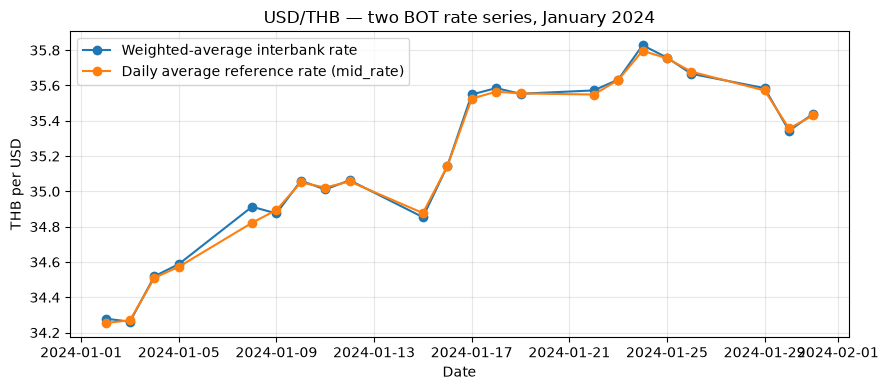

In [8]:
compare = ref_daily.merge(daily_usd[["period", "mid_rate"]], on="period", how="inner")
compare["rate"] = compare["rate"].astype(float)
compare["mid_rate"] = compare["mid_rate"].astype(float)

plt.figure(figsize=(9, 4))
plt.plot(compare["period"], compare["rate"], marker="o", label="Weighted-average interbank rate")
plt.plot(compare["period"], compare["mid_rate"], marker="o", label="Daily average reference rate (mid_rate)")
plt.title("USD/THB — two BOT rate series, January 2024")
plt.xlabel("Date")
plt.ylabel("THB per USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

## Notes

- `bond` (yield curve), `inflation`, and `gdp` namespaces aren't implemented on `BOTClient` yet — the
  actual BOT endpoint paths for those services haven't been confirmed, and this repo avoids
  hardcoding guessed API URLs. `bond_auction` and `reference_rate` (different, now-implemented
  services) shouldn't be confused with these.
- This notebook is exploratory only; it doesn't persist anything to `data/`. If any of these series
  need to be tracked over time, add a `bot`-source entry to `catalog.yaml` instead (see
  `macro_data/sources/bot.py`), which goes through the schema/store pipeline.